In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Retención estudiantil/Student dropout.csv', encoding='latin-1')

Mounted at /content/drive


### **Auditoría y Preparación de Datos**

Target Engineering:

El dataset original tiene 3 clases: Dropout, Graduate y Enrolled.
Problema: La clase Enrolled (Matriculado) es un estado "limbo". El estudiante no ha fracasado ni ha tenido éxito aún.

Solución: Al eliminarla, forzamos al modelo a encontrar patrones claros de éxito vs. fracaso. Esto "limpia la señal" para un primer modelo. Una vez que domines esto, podrías hacer un modelo multiclass, pero para riesgo, binario es el estándar.

In [2]:
# 1.1 Traducción de Columnas (Diccionario de Mapeo)
# Es vital trabajar en un idioma que el negocio entienda.
column_mapping = {
    'Marital status': 'Estado_Civil',
    'Application mode': 'Modo_Solicitud',
    'Application order': 'Orden_Solicitud',
    'Course': 'Curso',
    'Daytime/evening attendance': 'Turno_Diurno_Nocturno',
    'Previous qualification': 'Cualificacion_Previa',
    'Previous qualification (grade)': 'Nota_Cualificacion_Previa',
    'Nacionality': 'Nacionalidad',
    'Mother\'s qualification': 'Cualificacion_Madre',
    'Father\'s qualification': 'Cualificacion_Padre',
    'Mother\'s occupation': 'Ocupacion_Madre',
    'Father\'s occupation': 'Ocupacion_Padre',
    'Admission grade': 'Nota_Admision',
    'Displaced': 'Desplazado',
    'Educational special needs': 'Necesidades_Esp_Educativas',
    'Debtor': 'Deudor',
    'Tuition fees up to date': 'Matricula_Al_Dia',
    'Gender': 'Genero',
    'Scholarship holder': 'Becado',
    'Age at enrollment': 'Edad_al_Matricular',
    'International': 'Internacional',
    'Curricular units 1st sem (credited)': 'U_Curriculares_1sem_Acreditadas',
    'Curricular units 1st sem (enrolled)': 'U_Curriculares_1sem_Matriculadas',
    'Curricular units 1st sem (evaluations)': 'U_Curriculares_1sem_Evaluaciones',
    'Curricular units 1st sem (approved)': 'U_Curriculares_1sem_Aprobadas',
    'Curricular units 1st sem (grade)': 'U_Curriculares_1sem_Nota',
    'Curricular units 1st sem (without evaluations)': 'U_Curriculares_1sem_Sin_Eval',
    'Curricular units 2nd sem (credited)': 'U_Curriculares_2sem_Acreditadas',
    'Curricular units 2nd sem (enrolled)': 'U_Curriculares_2sem_Matriculadas',
    'Curricular units 2nd sem (evaluations)': 'U_Curriculares_2sem_Evaluaciones',
    'Curricular units 2nd sem (approved)': 'U_Curriculares_2sem_Aprobadas',
    'Curricular units 2nd sem (grade)': 'U_Curriculares_2sem_Nota',
    'Curricular units 2nd sem (without evaluations)': 'U_Curriculares_2sem_Sin_Eval',
    'Unemployment rate': 'Tasa_Desempleo',
    'Inflation rate': 'Tasa_Inflacion',
    'GDP': 'PIB',
    'Target': 'Target'
}

df.rename(columns=column_mapping, inplace=True)

# 1.2 Target Engineering: Filtro y Binarización
# Eliminamos 'Enrolled'
df_clean = df[df['Target'] != 'Enrolled'].copy()

# Mapeo Binario: Dropout (Clase Positiva/Riesgo) = 1, Graduate = 0
target_map = {'Dropout': 1, 'Graduate': 0}
df_clean['Target'] = df_clean['Target'].map(target_map)

# 1.3 Auditoría Rápida
print(f"Dimensiones finales: {df_clean.shape}")
print(f"Nulos encontrados: {df_clean.isnull().sum().sum()}")
print(f"Duplicados: {df_clean.duplicated().sum()}")
print(f"Distribución del Target (%): \n{df_clean['Target'].value_counts(normalize=True)}")

Dimensiones finales: (3630, 35)
Nulos encontrados: 0
Duplicados: 0
Distribución del Target (%): 
Target
0    0.60854
1    0.39146
Name: proportion, dtype: float64


### **Análisis Exploratorio de Datos (EDA)**

Multicolinealidad:
En este dataset, tenemos notas del 1er semestre y del 2do semestre.
Problema: Si a un alumno le va bien en el semestre 1, es muy probable (correlación > 0.8) que le vaya bien en el semestre 2.

Riesgo: Si ambas variables intervienen en una Regresión Logística, el modelo se "confunde" porque no sabe a cuál atribuirle el mérito, aumentando la varianza de los coeficientes. Los modelos de árboles (XGBoost/Random Forest) manejan esto mejor, pero es vital saber que existe redundancia.

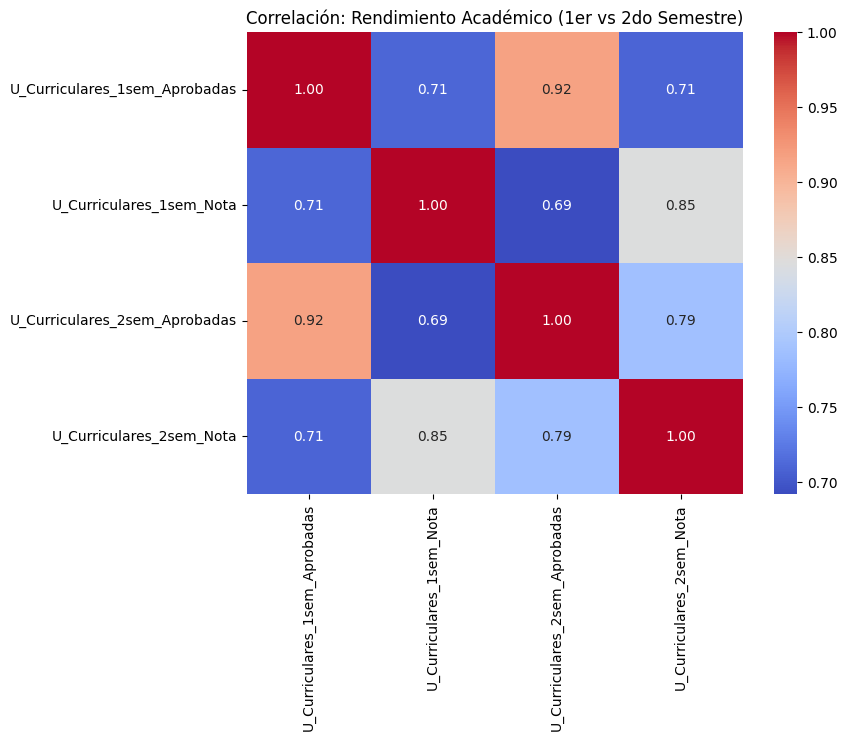

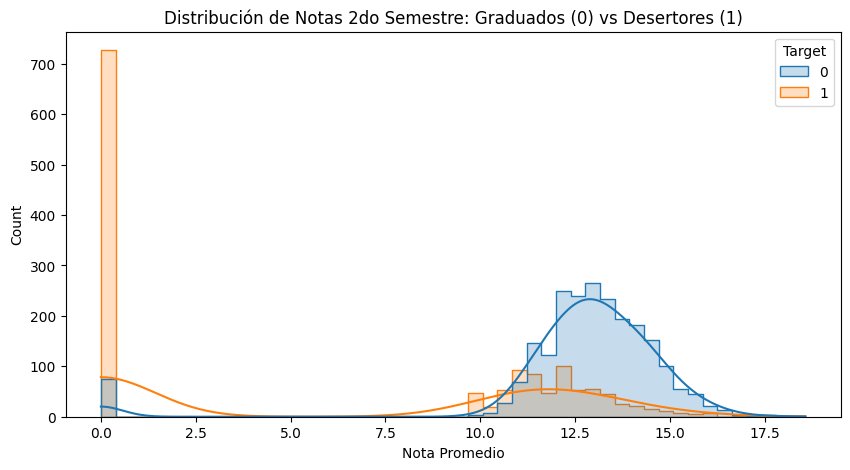

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2.1 Matriz de Correlación (Variables Académicas)
academic_cols = [
    'U_Curriculares_1sem_Aprobadas', 'U_Curriculares_1sem_Nota',
    'U_Curriculares_2sem_Aprobadas', 'U_Curriculares_2sem_Nota'
]

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[academic_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación: Rendimiento Académico (1er vs 2do Semestre)")
plt.show()
print(f"\n")

# 2.2 Distribución de Calificaciones por Target
# Visualizamos si las notas separan bien a los grupos
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='U_Curriculares_2sem_Nota', hue='Target', kde=True, element="step")
plt.title("Distribución de Notas 2do Semestre: Graduados (0) vs Desertores (1)")
plt.xlabel("Nota Promedio")
plt.show()

### **Pipeline de Entrenamiento**

* XGBoost: Es el estado del arte para datos tabulares. Maneja valores faltantes, relaciones no lineales y es robusto a outliers.

* Stratify:
Imagina que solo el 10% de los estudiantes desertan. Si hacemos un split aleatorio simple, podríamos tener mala suerte y que en el Test Set solo haya un 2% de desertores. stratify=y asegura que si hay 30% de abandono en el total, haya 30% en Train y 30% en Test.

In [5]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Separar Features (X) y Target (y)
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

# 3.1 Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantiene la proporción de Dropout
)

# 3.2 Entrenamiento del Modelo
# scale_pos_weight: Ayuda si hay desbalance (ej. más graduados que desertores)
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)
print("Entrenamiento completado.")

Entrenamiento completado.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:54:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### **Explicabilidad con SHAP**

SHAP (SHapley Additive exPlanations) nos dice cuánto empuja cada variable la probabilidad de abandono hacia arriba o abajo.

Interpretación Macro vs. Micro:
* Desempeño Académico (U_Curriculares_...): Suele ser el predictor #1. Si repruebas, te vas. Es la causa inmediata.
* Factores Socioeconómicos (PIB, Inflación): En este dataset, a menudo aparecen como secundarios. Indican el "clima" externo. Una crisis económica (PIB bajo) puede empujar a un alumno marginal a desertar, pero rara vez hace que un alumno de excelencia abandone.

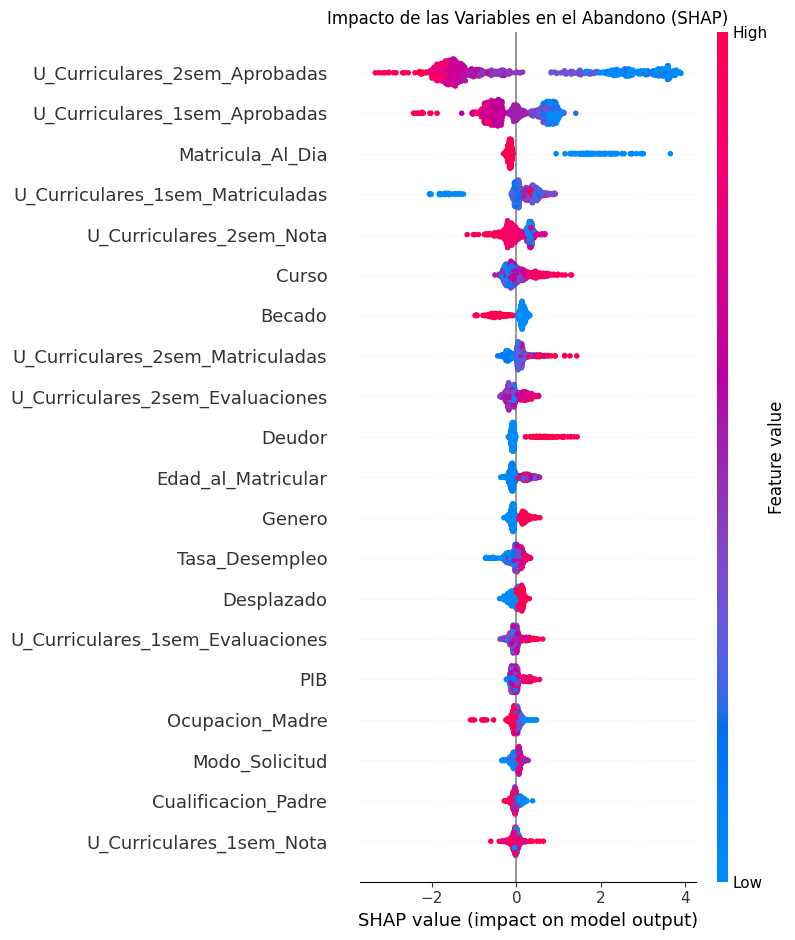

In [6]:
import shap

# Inicializar JS para gráficos interactivos (si usas notebook)
shap.initjs()

# 4.1 Cálculo de SHAP Values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 4.2 Summary Plot
plt.title("Impacto de las Variables en el Abandono (SHAP)")
shap.summary_plot(shap_values, X_test, plot_type="dot")

# Interpretación:
# - Puntos rojos a la derecha: Valores altos de la variable aumentan el riesgo de Drop.
# - Puntos azules a la derecha: Valores bajos de la variable aumentan el riesgo.
# Ejemplo: 'Matricula_Al_Dia' (Tuition fees up to date).
# Si es azul (0 = No al día), el SHAP value es muy positivo (aumenta riesgo).

### **Evaluación de Desempeño (Métricas de Negocio)**

Umbral (Threshold Tuning):
Por defecto, el modelo corta en 0.5 pero en educación
* Falso Negativo (FN): Predices que se gradúa, pero deserta. Costo: Perdemos al alumno sin intervenir. Es el error más grave.
* Falso Positivo (FP): Predices que deserta, pero se gradúa. Costo: Gastas recursos en tutorías para alguien que iba bien. Es un costo manejable.

Estrategia: Bajar el umbral para aumentar el Recall (Sensibilidad). Atrapar a todos los posibles desertores, aunque nos equivoquemos con algunos buenos estudiantes.

--- Métricas de Poder Predictivo ---
AUC: 0.9719 | Gini: 0.9438



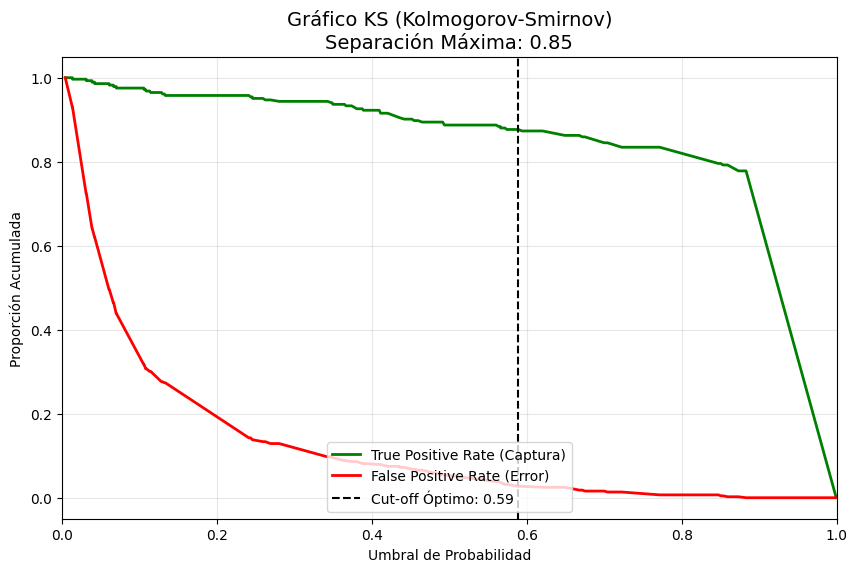

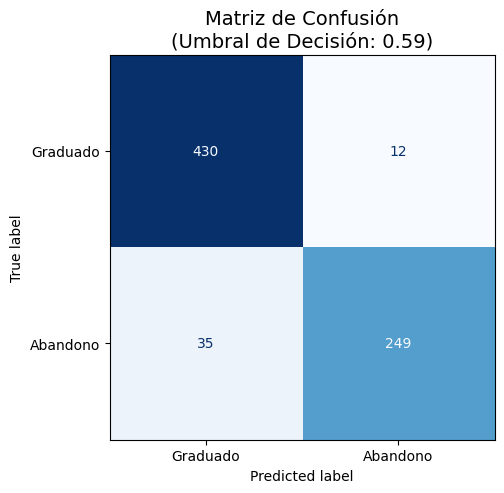

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# --- 1. CÁLCULO DE MÉTRICAS GLOBALES ---
auc_score = roc_auc_score(y_test, y_probs)
gini_score = 2 * auc_score - 1

print(f"--- Métricas de Poder Predictivo ---")
print(f"AUC: {auc_score:.4f} | Gini: {gini_score:.4f}\n")

# --- 2. CÁLCULO DEL KS Y UMBRAL ÓPTIMO ---
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
ks_values = tpr - fpr
max_ks_idx = np.argmax(ks_values)
max_ks = ks_values[max_ks_idx]
optimal_cutoff = thresholds[max_ks_idx]

# --- 3. GRÁFICA 1: CURVA KS (Independiente) ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, label='True Positive Rate (Captura)', color='green', lw=2)
plt.plot(thresholds, fpr, label='False Positive Rate (Error)', color='red', lw=2)
plt.axvline(optimal_cutoff, color='black', linestyle='--',
            label=f'Cut-off Óptimo: {optimal_cutoff:.2f}')

plt.title(f'Gráfico KS (Kolmogorov-Smirnov)\nSeparación Máxima: {max_ks:.2f}', fontsize=14)
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('Proporción Acumulada')
plt.legend(loc='lower center')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show() # Termina la primera salida gráfica
print("\n")

# --- 4. GRÁFICA 2: MATRIZ DE CONFUSIÓN ---
# Aplicamos el umbral para la clasificación binaria
y_pred_optimized = (y_probs >= optimal_cutoff).astype(int)
cm = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Graduado', 'Abandono'])
# Nota: pasamos plt.gca() (get current axis) para que use la figura que acabamos de crear
disp.plot(cmap='Blues', values_format='d', ax=plt.gca(), colorbar=False)

plt.title(f'Matriz de Confusión\n(Umbral de Decisión: {optimal_cutoff:.2f})', fontsize=14)
plt.grid(False) # Evita líneas sobre la matriz si el estilo global tiene grid
plt.show() # Termina la segunda salida gráfica

### **Gráfico KS**
* Lo que buscas: Quieres que la línea Verde (Desertores capturados) suba rápido y que la línea Roja (Falsas alarmas) se mantenga abajo el mayor tiempo posible.
* La "Boca": El espacio entre la línea verde y la roja es la "boca" del KS. Mientras más grande sea esa boca, mejor es tu modelo discriminando.
* El Cut-off: La línea punteada negra te dice el punto exacto de probabilidad donde esa distancia es máxima. Matemáticamente, ese es tu mejor umbral para balancear errores.

### **La Matriz de Confusión**

* Cuadrante Inferior Derecho (True Positives): Debería haber aumentado. Estos son los alumnos en riesgo que sí detectamos.
* Cuadrante Inferior Izquierdo (False Negatives): Debería haber disminuido. Estos son los alumnos que perdimos porque el modelo no los vio venir. En educación, este es el error más costoso.
* Cuadrante Superior Derecho (False Positives): Probablemente aumentó un poco. Son alumnos que iban bien pero marcamos como riesgo. Es el "costo" de ser más precavidos (invertir en tutorías "por si acaso").

### **Coeficiente Gini (0 a 1)**
Si tu Gini es 0.60, significa que tu modelo es un 60% mejor que lanzar una moneda al aire para adivinar quién abandona. En ciencias sociales y comportamiento humano, un Gini > 0.6 es un resultado muy robusto.

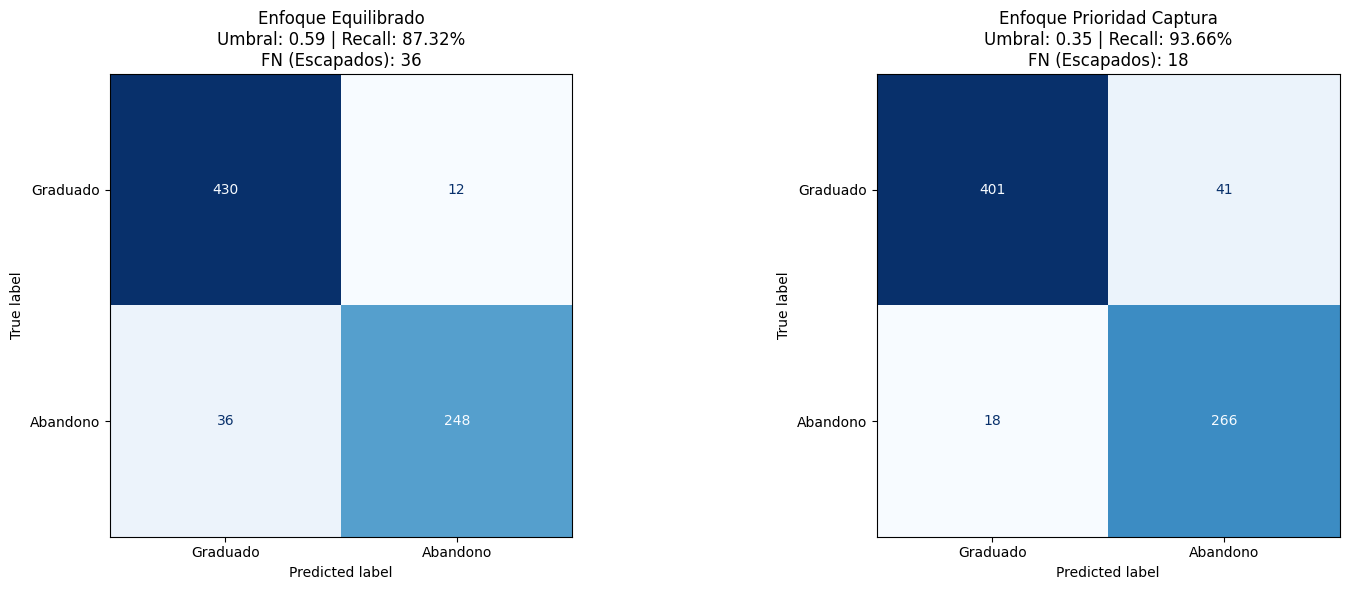

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Definimos los dos escenarios basados en tus resultados
umbrales = [0.59, 0.35]
nombres = ['Enfoque Equilibrado', 'Enfoque Prioridad Captura']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, u in enumerate(umbrales):
    # Generamos la predicción según el umbral
    y_pred = (y_probs >= u).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    # Cálculo de métricas clave para el título
    recall = cm[1,1] / (cm[1,1] + cm[1,0])
    fn = cm[1,0] # Los desertores que se nos escaparon

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Graduado', 'Abandono'])
    disp.plot(cmap='Blues', ax=axes[i], values_format='d', colorbar=False)

    axes[i].set_title(f"{nombres[i]}\nUmbral: {u} | Recall: {recall:.2%}\nFN (Escapados): {fn}")

plt.tight_layout()
plt.show()